In [56]:
from pathlib import Path
import sys
import os

%load_ext autoreload
%autoreload 2

dir = Path().resolve().parents[1]

if dir not in sys.path:
    sys.path.append(str(dir))   

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [57]:
import torch
from pathlib import Path
from nn import Unet1D
from config import Config
from utils import posterior_beta, log_transform, inverse_standard, one_step_rolling_forecast, compute_aic_log_likelihood, compute_aic_log_likelihood_stdresid, test_stationarity, plot_distribution, load_and_split_snp500
from diffusion import reverse
import time
import yfinance as yf
import math
import matplotlib.pyplot as plt
import scipy.stats as stats
import numpy as np
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import acf, pacf, adfuller
import statsmodels.api as sm
from statsmodels.tsa.ar_model import AutoReg
from arch import arch_model
import joblib

In [58]:
rng = np.random.default_rng()

In [59]:
window = 128
data = load_and_split_snp500(window, transform_fn=log_transform)

In [60]:
train_snp500 = data["train"]
len(train_snp500)

2413

In [61]:
SYN_PATH = dir / "data" / "syn_data_128.joblib"
synthetic_data_all = joblib.load(SYN_PATH)

In [62]:
stride = window

empirical_window = []
for i in range(0, len(train_snp500) - window + 1, stride):
    empirical_window.append(train_snp500[i:i+window])

empirical_window = np.array(empirical_window)

In [63]:
synthetic_data = rng.choice(synthetic_data_all, size=len(empirical_window), axis=0, replace=False)

### Normal Plot

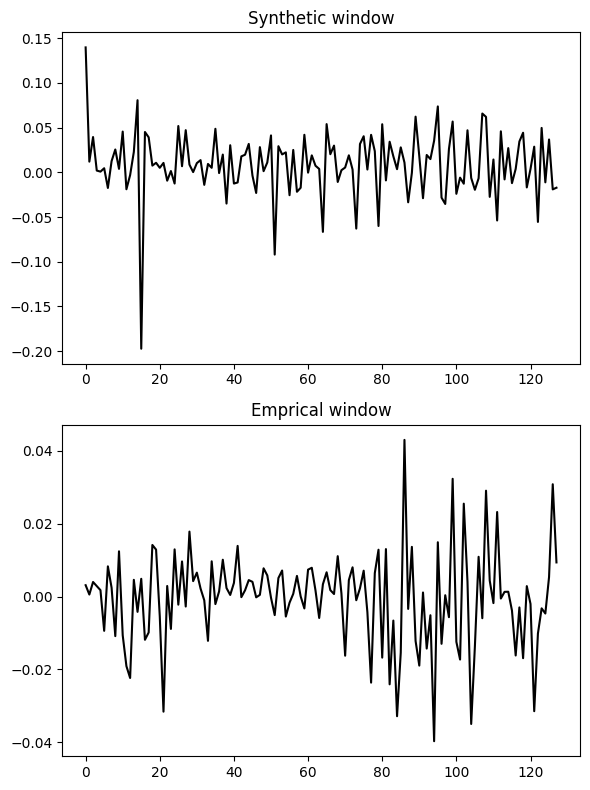

In [11]:
"""
  Note that the generated synthetic window cant be indexed by time since it doesnt preserve time index.
  We would label it as what a typical n-window return looked like from the training data.
"""

fig, ax = plt.subplots(figsize=(6, 8), nrows=2)

ax[0].plot(synthetic_data[0], c="black")
ax[1].plot(empirical_window[0], c="black")
ax[0].set_title("Synthetic window")
ax[1].set_title("Emprical window")

fig.tight_layout()
plt.show()

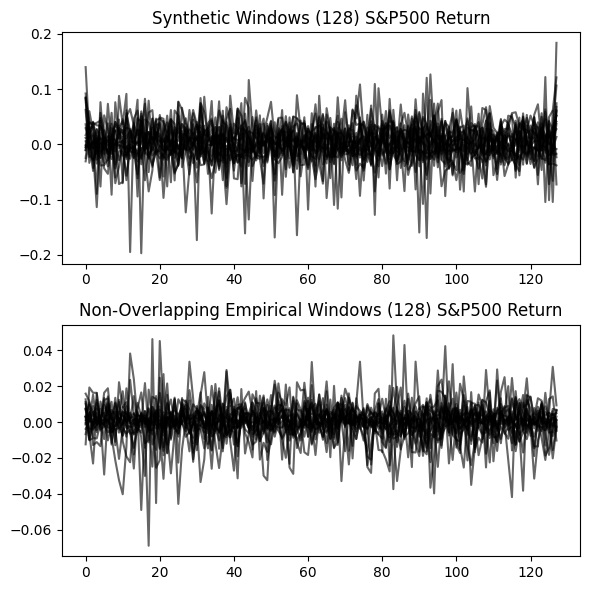

In [12]:
fig, ax = plt.subplots(figsize=(6, 6), nrows=2)
for i in range(len(synthetic_data)):
  ax[0].plot(synthetic_data[i], alpha=0.6, c="black")

ax[0].set_title(f"Synthetic Windows ({window}) S&P500 Return")

for i in range(len(empirical_window)):
  ax[1].plot(empirical_window[i], alpha=0.6, c="black")

ax[1].set_title(f"Non-Overlapping Empirical Windows ({window}) S&P500 Return")

fig.tight_layout()
plt.show()

### Stationarity Tests

In [12]:
adf_emp = test_stationarity(empirical_window)
adf_syn = test_stationarity(synthetic_data)

In [13]:
rejections_1_syn = 0
rejections_5_syn = 0
rejections_10_syn = 0

rejections_1_emp = 0
rejections_5_emp = 0
rejections_10_emp = 0

for idx, res in enumerate(adf_syn):
  p_value = res[1]

  if p_value < 0.01:
    rejections_1_syn += 1
  if p_value < 0.05:
      rejections_5_syn += 1
  if p_value < 0.10:
      rejections_10_syn += 1

for idx, res in enumerate(adf_emp):
  p_value = res[1]

  if p_value < 0.01:
    rejections_1_emp += 1
  if p_value < 0.05:
      rejections_5_emp += 1
  if p_value < 0.10:
      rejections_10_emp += 1

In [14]:
print("Synthetic")
print(f"Rejection rate p-value(0.01) : {rejections_1_syn / len(adf_syn):.2f}")
print(f"Rejection rate p-value(0.05) : {rejections_5_syn / len(adf_syn):.2f}")
print(f"Rejection rate p-value(0.10) : {rejections_10_syn / len(adf_syn):.2f}")
print("="*50)

print("Empirical")
print(f"Rejection rate p-value(0.01) : {rejections_1_emp / len(adf_emp):.2f}")
print(f"Rejection rate p-value(0.05) : {rejections_5_emp / len(adf_emp):.2f}")
print(f"Rejection rate p-value(0.10) : {rejections_10_emp / len(adf_emp):.2f}")

Synthetic
Rejection rate p-value(0.01) : 1.00
Rejection rate p-value(0.05) : 1.00
Rejection rate p-value(0.10) : 1.00
Empirical
Rejection rate p-value(0.01) : 1.00
Rejection rate p-value(0.05) : 1.00
Rejection rate p-value(0.10) : 1.00


### Theoretical Distribution Comparison  

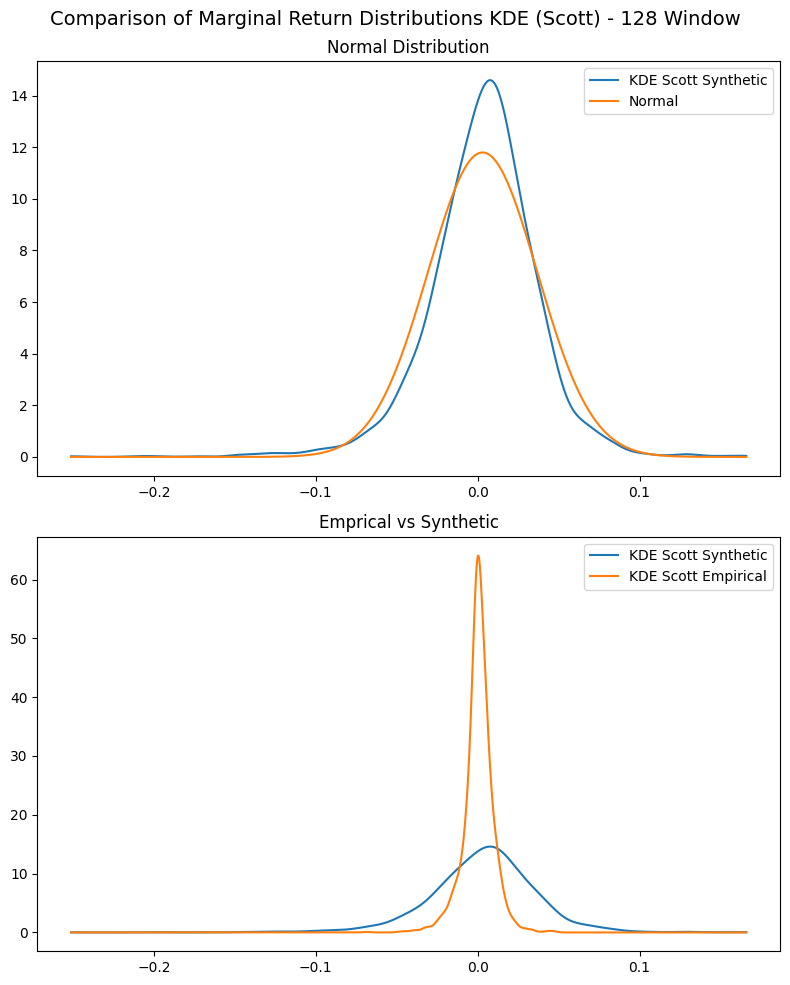

In [15]:
plot_distribution(synthetic_data, empirical_window)

### Log-Likelihood AIC Comparison

In [16]:
emp_len = len(empirical_window)
t_wins_emp, norm_wins_emp, _ = compute_aic_log_likelihood(empirical_window)

print(f"T rate : ", t_wins_emp / emp_len)
print(f"Norm rate : ", norm_wins_emp / emp_len)

T rate :  0.7777777777777778
Norm rate :  0.2222222222222222


In [17]:
syn_len = len(empirical_window)
t_rates = []
norm_rates = []

for i in range(1000):
  synthetic_data_rnd = rng.choice(synthetic_data_all, size=syn_len, axis=0, replace=False)

  t_wins_syn, norm_wins_syn, _ = compute_aic_log_likelihood(synthetic_data_rnd)
  t_rate = t_wins_syn / syn_len
  norm_rate = norm_wins_syn / syn_len
  t_rates.append(t_rate)
  norm_rates.append(norm_rate)

t_rates = np.array(t_rates)
norm_rates = np.array(norm_rates)

In [18]:
print("Mean t-rate:", t_rates.mean())
print("Std t-rate:", t_rates.std())
print("Mean norm-rate:", norm_rates.mean())
print("Std norm-rate:", norm_rates.std())

Mean t-rate: 0.8955555555555557
Std t-rate: 0.07131048439875573
Mean norm-rate: 0.10444444444444445
Std norm-rate: 0.07131048439875573


### QQ-Plot

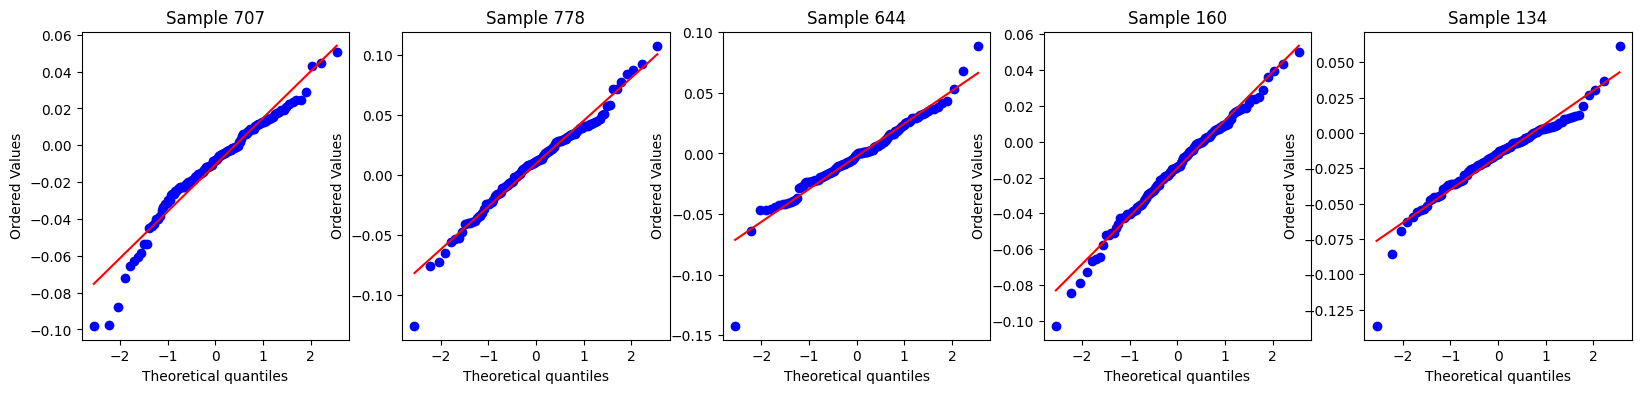

In [19]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
indices = np.random.choice(len(synthetic_data_all), 5, replace=False)

for ax, i in zip(axes, indices):
    stats.probplot(synthetic_data_all[i], dist="norm", plot=ax)
    ax.set_title(f"Sample {i}")

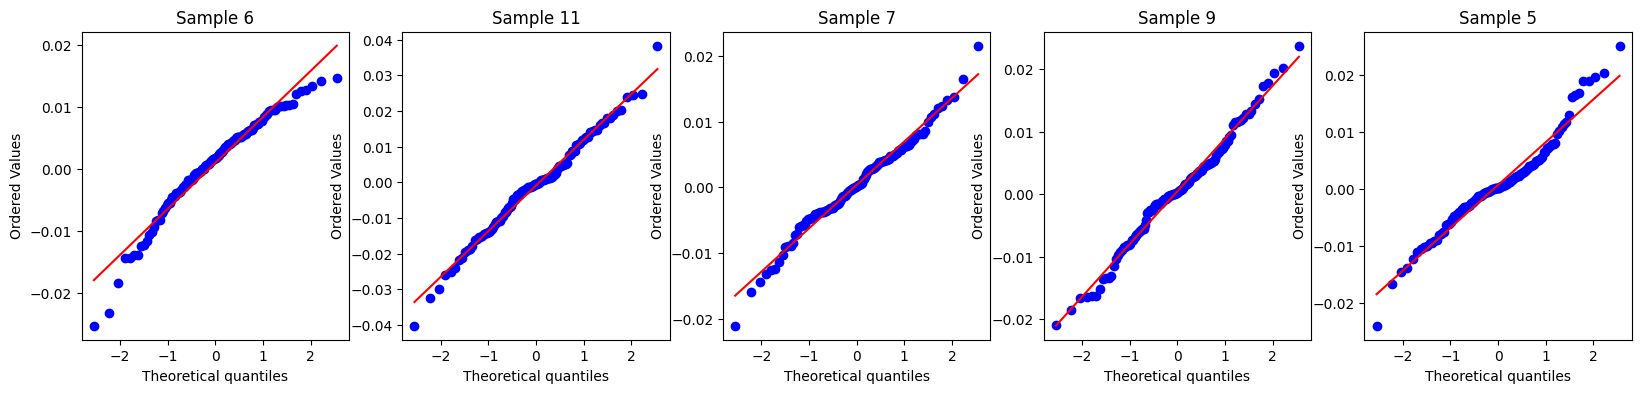

In [20]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
indices = np.random.choice(len(empirical_window), 5, replace=False)

for ax, i in zip(axes, indices):
    stats.probplot(empirical_window[i], dist="norm", plot=ax)
    ax.set_title(f"Sample {i}")

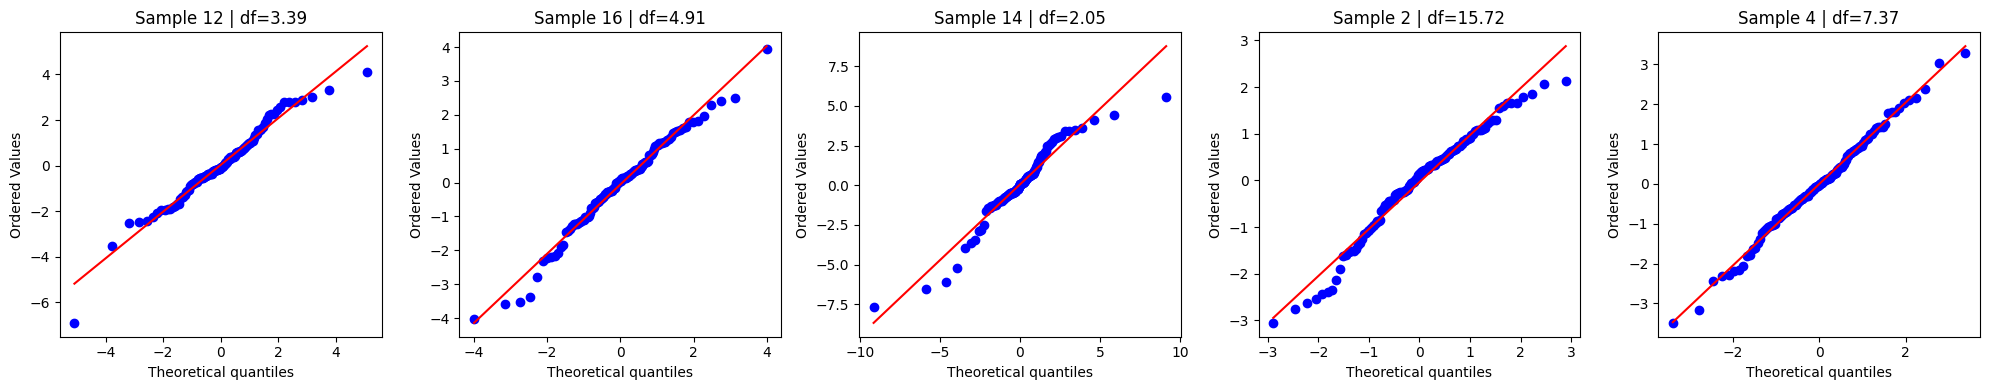

In [21]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
indices = np.random.choice(len(empirical_window), 5, replace=False)

for ax, i in zip(axes, indices):
    sample = empirical_window[i]

    df, loc, scale = stats.t.fit(sample)

    standardized = (sample - loc) / scale

    stats.probplot(
        standardized,
        dist=stats.t,
        sparams=(df,),
        plot=ax
    )

    ax.set_title(f"Sample {i} | df={df:.2f}")

plt.tight_layout()
plt.show()

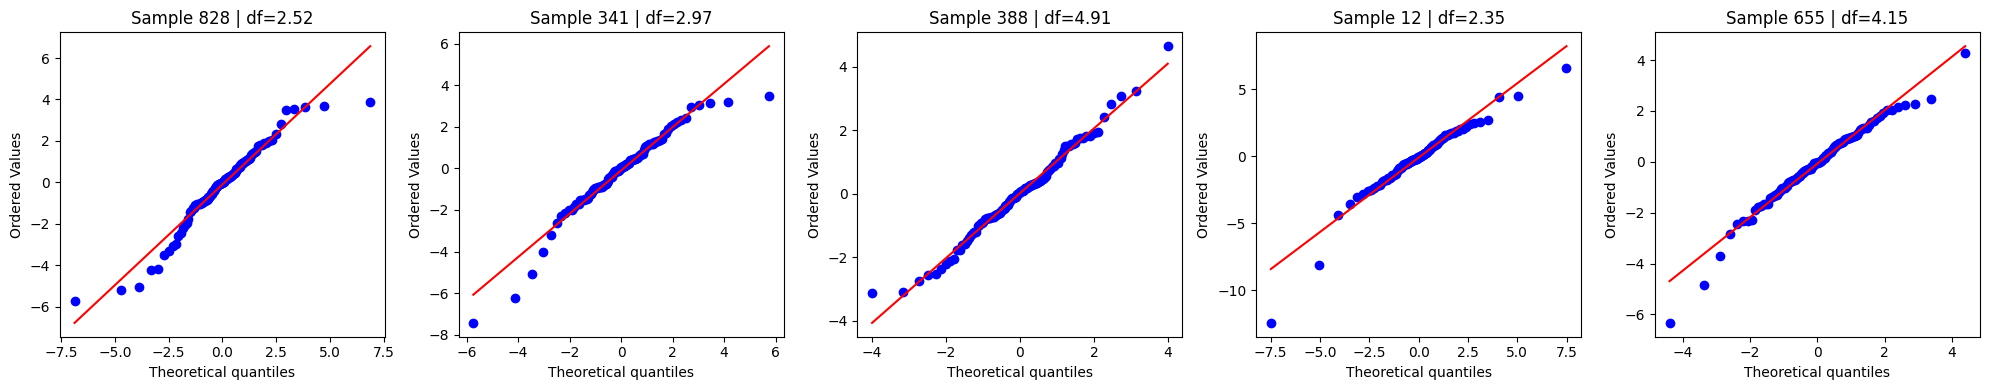

In [22]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
indices = np.random.choice(len(synthetic_data_all), 5, replace=False)

for ax, i in zip(axes, indices):
    sample = synthetic_data_all[i]

    df, loc, scale = stats.t.fit(sample)

    standardized = (sample - loc) / scale

    stats.probplot(
        standardized,
        dist=stats.t,
        sparams=(df,),
        plot=ax
    )

    ax.set_title(f"Sample {i} | df={df:.2f}")

plt.tight_layout()
plt.show()

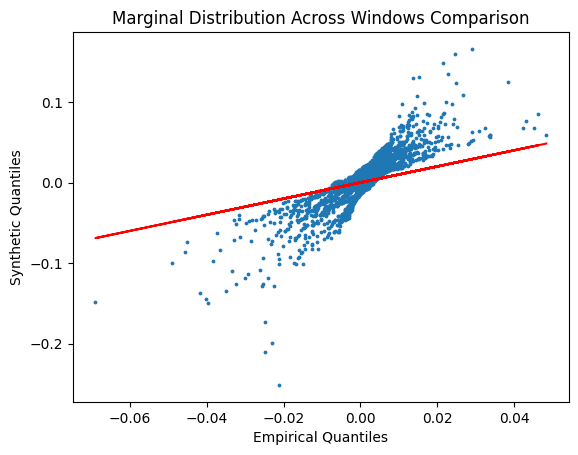

In [23]:
x = np.sort(empirical_window)
y = np.sort(synthetic_data)

plt.scatter(x, y, s=3)
plt.plot(x, x, color='red') # reference target
plt.xlabel("Empirical Quantiles")
plt.ylabel("Synthetic Quantiles")
plt.title("Marginal Distribution Across Windows Comparison")
plt.show()

In [24]:
kurtosis_emp = stats.kurtosis(empirical_window.reshape(-1))
skew_emp = stats.skew(empirical_window.reshape(-1))
kurtosis_syn = stats.kurtosis(synthetic_data.reshape(-1))
skew_syn = stats.skew(synthetic_data.reshape(-1))

print("="*10 + "Empirical" + "="*10)
print(f"Kurtosis : {kurtosis_emp}\nSkewness : {skew_emp}")

print("="*10 + "Synthetic" + "="*10)
print(f"Kurtosis : {kurtosis_syn}\nSkewness : {skew_syn}")

==========Empirical==========
Kurtosis : 4.584840460148701
Skewness : -0.47061797986958415
==========Synthetic==========
Kurtosis : 4.701164546663105
Skewness : -0.6601252092383113


## Intra-Window Evaluation

In [25]:
lags=10

In [ ]:
def compute_acf_matrix(windows, lags):
  return np.array([
      acf(w, nlags=lags, fft=True)
      for w in windows
  ])

def compute_ljung(windows, p_lag):
  """
    Returns:
    1. rejection_rate: rejection rate across windows
  """
  rejection_rate = 0

  for window in windows:
    res = sm.stats.acorr_ljungbox(window, lags=p_lag)
    lb_pvalue = res["lb_pvalue"].iloc[-1]
    rejection_rate += 1 if lb_pvalue < 0.05 else False

  return rejection_rate / len(windows)

def compare_acf_matrix(lag, acf_matrix):
  acf_value = acf_matrix[1:, lag]
  return np.mean(acf_value), np.std(acf_value)  

def compare_acf_matrices(lag, m1, m2):
  acf_m1 = m1[:, lag]
  acf_m2 = m2[:, lag]

  acf_m1_std = np.std(acf_m1)
  acf_m2_std = np.std(acf_m2)

  acf_m1_mean = np.mean(acf_m1)
  acf_m2_mean = np.mean(acf_m2)

  acf_m1_percentiles = np.percentile(m1[1:, lag], [25, 50, 75])
  acf_m2_percentiles = np.percentile(m2[1:, lag], [25, 50, 75])

  return {
    "m1_std": acf_m1_std,
    "m2_std": acf_m2_std,
    "m1_mean": acf_m1_mean,
    "m2_mean": acf_m2_mean,
    "m1_percentiles": acf_m1_percentiles,
    "m2_percentiles": acf_m2_percentiles,
  }

In [56]:
SAMPLES = 1000
LAGS = 10
syn_reject_rate_list = []
rng = np.random.default_rng()

for i in range(SAMPLES):
  syn_sampled_window = rng.choice(synthetic_data_all, size=len(empirical_window), replace=False, axis=0)
  syn_rejection_rate = compute_ljung(syn_sampled_window, p_lag=LAGS)
  syn_reject_rate_list.append(syn_rejection_rate)

emp_reject_rate = compute_ljung(empirical_window, p_lag=LAGS)
syn_reject_std = np.std(syn_reject_rate_list)
syn_reject_mean = np.mean(syn_reject_rate_list)

In [57]:
print(f"Empirical rejection rate: ", emp_reject_rate)
print(f"Synthetic rejection rate mean: ", syn_reject_mean)
print(f"Synthetic rejection rate std: ", syn_reject_std)

Empirical rejection rate:  0.1111111111111111
Synthetic rejection rate mean:  0.7138888888888889
Synthetic rejection rate std:  0.10621867730021593


Figure(640x480)


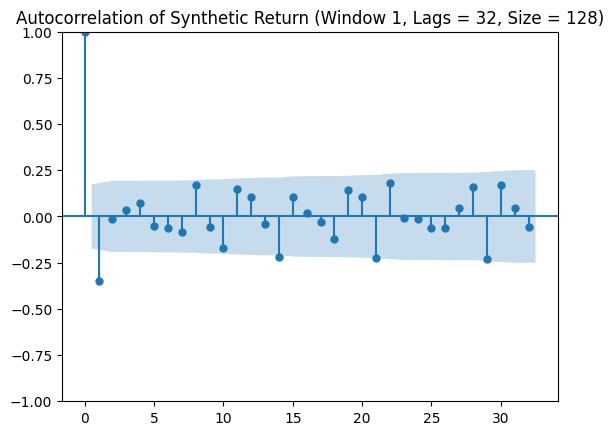

In [59]:
print(plot_acf(synthetic_data[1], lags=32, title="Autocorrelation of Synthetic Return (Window 1, Lags = 32, Size = 128)"))

Figure(640x480)


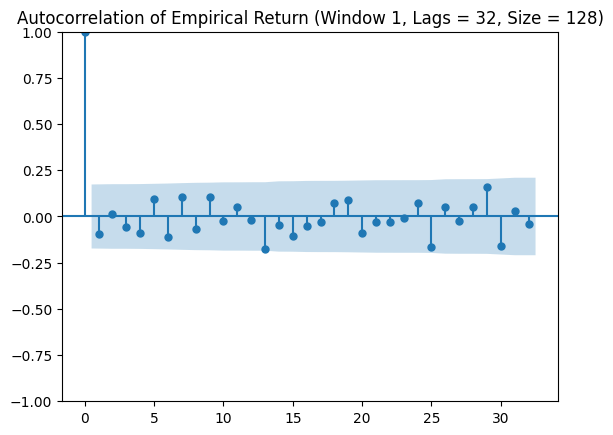

In [60]:
print(plot_acf(empirical_window[1], lags=32, title="Autocorrelation of Empirical Return (Window 1, Lags = 32, Size = 128)"))

In [24]:
def get_residuals(window, lags=1):
    model = AutoReg(window, lags=lags, old_names=False).fit()
    return model.resid

# compute AR(1)
res_emp = np.array([get_residuals(w) for w in empirical_window])
res_syn = np.array([get_residuals(w) for w in synthetic_data_all])

def arch_test(residuals, ddof):
    _, pval, _, _ = sm.stats.diagnostic.het_arch(residuals, ddof=ddof, nlags=10)
    return pval

# ddof = 2 because the residuals comes from regression model which have lag =1 and intercept 1 = 2
# Or common seeting for ddof = p + q for ARMA(p, q)
arch_emp = [arch_test(r, 2) for r in res_emp]

syn_arch_rejection_list = []
for i in range(1000):
  res_sampled = rng.choice(res_syn, size=len(res_emp), replace=False, axis=0)
  arch_syn_samples = [arch_test(r, 2) for r in res_sampled]
  
  rejection = sum(p_value < 0.05 for p_value in arch_syn_samples)
  syn_arch_rejection_list.append(rejection / len(arch_syn_samples))

emp_arch_rejection_rate = sum(p_value < 0.05 for p_value in arch_emp) / len(arch_emp)
syn_arch_rejection_list = np.array(syn_arch_rejection_list)

In [50]:
print("Empirical rejection rate : ", emp_arch_rejection_rate)

Empirical rejection rate :  0.3888888888888889


In [26]:
standard_error = syn_arch_rejection_list.std() / np.sqrt(100)

print("Syn LM-ARCH Tests Rejection Rate Mean : ", syn_arch_rejection_list.mean())
print("Syn LM-ARCH Tests Rejection Rate STD : ", syn_arch_rejection_list.std())
print("Syn LM-ARCH Tests Rejection Rate Standard Error : ", standard_error)

Syn LM-ARCH Tests Rejection Rate Mean :  0.0765
Syn LM-ARCH Tests Rejection Rate STD :  0.06321799927314029
Syn LM-ARCH Tests Rejection Rate Standard Error :  0.006321799927314029


In [27]:
res_squared_emp = res_emp ** 2
res_squared_syn = res_syn ** 2

Figure(640x480)


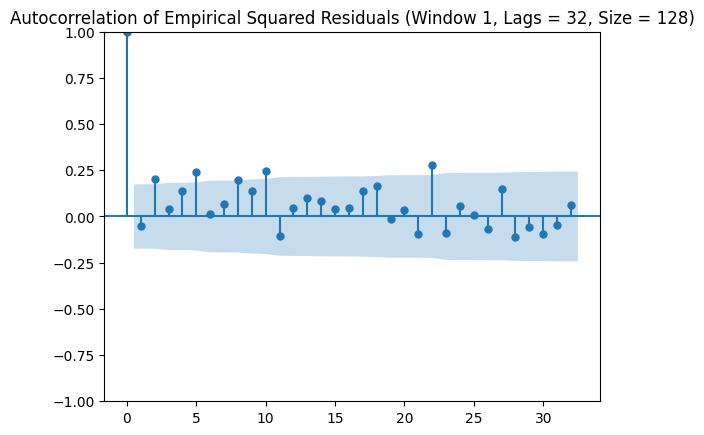

In [36]:
print(plot_acf(res_squared_emp[0], lags=32, title="Autocorrelation of Empirical Squared Residuals (Window 1, Lags = 32, Size = 128)"))

Figure(640x480)


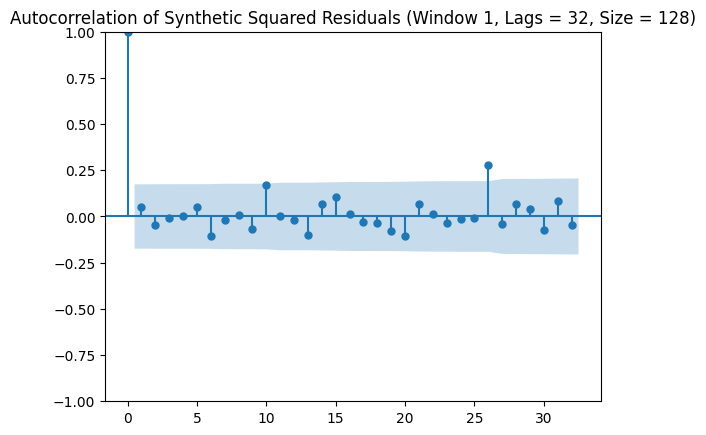

In [48]:
print(plot_acf(res_squared_syn[4], lags=32, title="Autocorrelation of Synthetic Squared Residuals (Window 1, Lags = 32, Size = 128)"))

In [80]:
SAMPLES = 1000
LAGS = 10
syn_reject_rate_list = []
rng = np.random.default_rng()

for i in range(SAMPLES):
  syn_sampled_squared_res = rng.choice(res_squared_syn, size=len(res_squared_emp), replace=False, axis=0)
  syn_rejection_rate = compute_ljung(syn_sampled_squared_res, p_lag=LAGS)
  syn_reject_rate_list.append(syn_rejection_rate)

emp_reject_rate = compute_ljung(res_squared_emp, p_lag=LAGS)
syn_reject_std = np.std(syn_reject_rate_list)
syn_reject_mean = np.mean(syn_reject_rate_list)

In [81]:
print(f"Empirical squared residuals rejection rate: ", emp_reject_rate)
print(f"Synthetic squared residuals rejection rate mean: ", syn_reject_mean)
print(f"Synthetic squared residuals rejection rate std: ", syn_reject_std)

Empirical squared residuals rejection rate:  0.4444444444444444
Synthetic squared residuals rejection rate mean:  0.0805
Synthetic squared residuals rejection rate std:  0.06376555728836922


### GARCH Evaluation under Fixed Window Segmentation

In [65]:
def compute_arch(windows, mean="zero", vol="GARCH", p=1, q=1, dist="t"):
  """
    Automatic scaling by * 100.
  """
  result = []
  n = len(windows)

  for i in range(n):
    model = arch_model(
      windows[i] * 100,
      mean=mean,
      vol=vol,
      p=p,
      q=q,
      dist=dist
    )

    res = model.fit(disp="off")
    result.append(res)

  return result

In [66]:
arch_emp = compute_arch(empirical_window)
arch_syn = compute_arch(synthetic_data_all)

In [67]:
rho_emp = np.array([
    res.params["alpha[1]"] + res.params["beta[1]"]
    for res in arch_emp
])

rho_syn_all = np.array([
    res.params["alpha[1]"] + res.params["beta[1]"]
    for res in arch_syn
])

metrics = []
rng = np.random.default_rng()

for _ in range(1000):
    idx = rng.choice(len(rho_syn_all), size=len(rho_emp), replace=False)
    rho_syn = rho_syn_all[idx]

    dist = stats.wasserstein_distance(rho_emp, rho_syn)
    metrics.append(dist)

Text(0.5, 1.0, 'Distribution of Distance (Empirical vs Synthetic)')

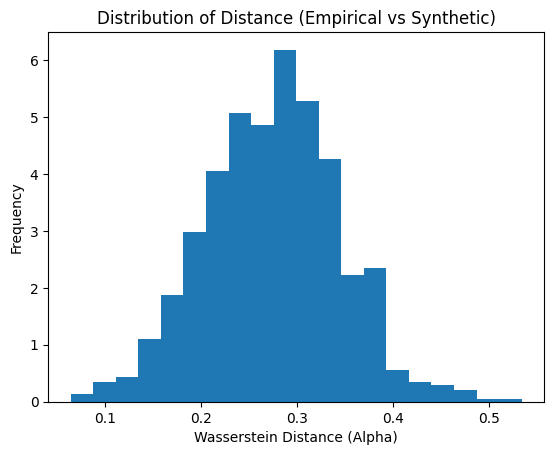

In [68]:
plt.hist(metrics, bins=20, density=True)
plt.xlabel("Wasserstein Distance (Alpha)")
plt.ylabel("Frequency")
plt.title("Distribution of Distance (Empirical vs Synthetic)")

In [69]:
metrics = np.array(metrics)
print("Wassertein mean : ", metrics.mean())
print("Wassertein std : ", metrics.std())

Wassertein mean :  0.27519936131999895
Wassertein std :  0.07011341921496775


Text(0.5, 1.0, 'Distribution of Distance (1000 trials)')

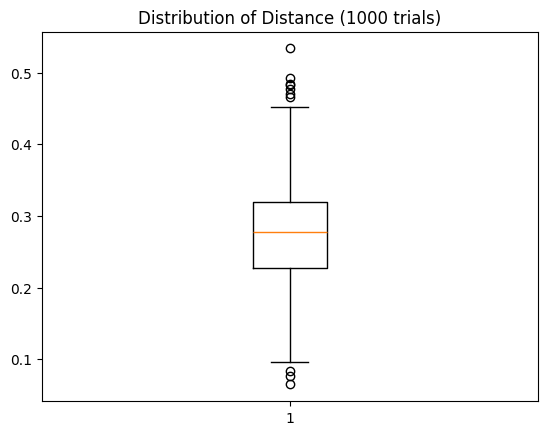

In [70]:
plt.boxplot(metrics)
plt.title("Distribution of Distance (1000 trials)")

Text(0, 0.5, 'CDF')

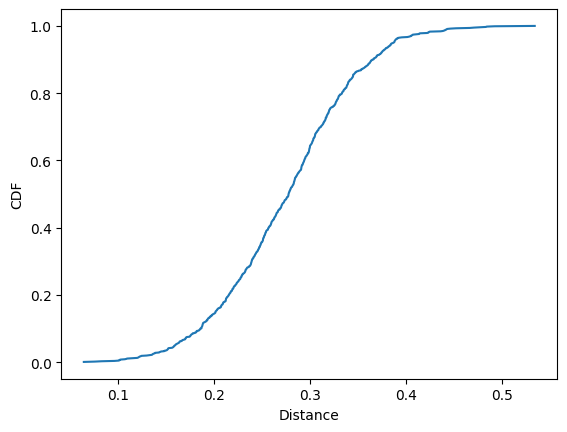

In [71]:
x = np.sort(metrics)
y = np.arange(1, len(x)+1) / len(x)

plt.plot(x, y)
plt.xlabel("Distance")
plt.ylabel("CDF")

In [72]:
SIM_DATA_PATH = dir / "data" / "sim_data_128.joblib"
SIM_DATA_PATH

WindowsPath('D:/CodingHenry/research_MBKM/data/sim_data_128.joblib')

In [73]:
sim_data = joblib.load(SIM_DATA_PATH)
sim_data

{'window_size': 128,
 'config': {'mean': 'zero', 'p': 1, 'q': 1, 'burn': 500},
 'sim_data': array([[ 5.29942976e-03, -6.84259991e-03, -5.85815016e-03, ...,
          2.48263798e-03,  6.76797997e-03, -2.58093752e-02],
        [-6.94605379e-04,  9.56326770e-03, -1.05323933e-02, ...,
         -1.38813137e-02,  4.15674373e-04,  5.32948461e-03],
        [-5.98405676e-03, -4.94169916e-03,  2.64930997e-04, ...,
         -6.87283657e-03,  1.68934399e-03,  1.85764855e-03],
        ...,
        [ 2.27412952e-03,  2.29220753e-03, -9.87870733e-03, ...,
          1.28993419e-05, -6.36763550e-04,  7.41193227e-03],
        [-2.50092401e-03,  2.16287773e-03, -2.15283376e-03, ...,
          3.20070998e-04, -6.84596710e-03, -7.81358954e-03],
        [-7.36417597e-03, -7.99963344e-03,  3.05295842e-03, ...,
         -1.54809931e-02, -2.44446948e-02,  1.68417622e-02]],
       shape=(36, 128))}

In [74]:
sim_data_returns = sim_data["sim_data"]

In [75]:
len(sim_data_returns)

36

In [76]:
# baseline
split = len(sim_data_returns) // 2

garch_A = sim_data_returns[:split]
garch_B = sim_data_returns[split:]

len(garch_A), len(garch_B)

(18, 18)

In [77]:
arch_A = compute_arch(garch_A)
arch_B = compute_arch(garch_B)

In [78]:
rho_A = [r.params["alpha[1]"] + r.params["beta[1]"] for r in arch_A]
rho_B = [r.params["alpha[1]"] + r.params["beta[1]"] for r in arch_B]

W_baseline = stats.wasserstein_distance(rho_A, rho_B)

In [79]:
print("t vs t")
print("Wassertein baseline : ", W_baseline)
print("Wassertein emp vs syn mean : ", metrics.mean())
print("Wassertein emp vs syn std : ", metrics.std())
print("Difference in baseline variability scale : ", metrics.mean() / W_baseline)

t vs t
Wassertein baseline :  0.12620991097506098
Wassertein emp vs syn mean :  0.27519936131999895
Wassertein emp vs syn std :  0.07011341921496775
Difference in baseline variability scale :  2.1804893070115403


In [ ]:
print("Wassertein baseline : ", W_baseline)
print("Wassertein emp vs syn mean : ", metrics.mean())
print("Wassertein emp vs syn std : ", metrics.std())
print("Difference in baseline variability scale : ", metrics.mean() / W_baseline)

Wassertein baseline :  0.03788919916332122
Wassertein emp vs syn mean :  0.27866442379578815
Wassertein emp vs syn std :  0.06692369253799557
Difference in baseline variability scale :  7.354719285425021


### ARCH residuals diagnostics

In [80]:
def ljung_box_diagnostics(models, lags=20):
    n = len(models)

    rej = np.zeros((n, lags))
    pvals = np.zeros((n, lags))

    rej_sq = np.zeros((n, lags))
    pvals_sq = np.zeros((n, lags))

    for i, res in enumerate(models):

        std_resid = res.std_resid
        std_resid_sq = std_resid ** 2
        
        lb = sm.stats.acorr_ljungbox(std_resid, lags=lags, return_df=True)
        lb_sq = sm.stats.acorr_ljungbox(std_resid_sq, lags=lags, return_df=True)

        pvals[i, :] = lb["lb_pvalue"].values
        rej[i, :] = (lb["lb_pvalue"].values < 0.05).astype(int)

        pvals_sq[i, :] = lb_sq["lb_pvalue"].values
        rej_sq[i, :] = (lb_sq["lb_pvalue"].values < 0.05).astype(int)

    return rej, pvals, rej_sq, pvals_sq

In [81]:
def compare_ljung_box_arch_resampled(arch_emp, arch_syn, lags=20, n_iter=500, seed=42):
    rng = np.random.default_rng(seed)

    print("\n================ LJUNG-BOX COMPARISON (RESAMPLED) ================\n")

    print(">>> EMPIRICAL DATA")
    rej_e, p_e, rej_sq_e, p_sq_e = ljung_box_diagnostics(arch_emp, lags=lags)

    emp_lag = rej_e.mean(axis=0)
    emp_global = rej_e.mean()

    emp_sq_lag = rej_sq_e.mean(axis=0)
    emp_sq_global = rej_sq_e.mean()

    print("Standardized Residuals")
    print("Lag-wise rejection rate:", emp_lag)
    print("GLOBAL rejection rate   :", emp_global)
    print("Avg p-values           :", p_e.mean(axis=0))

    print("\nSquared Standardized Residuals")
    print("Lag-wise rejection rate:", emp_sq_lag)
    print("GLOBAL rejection rate   :", emp_sq_global)
    print("Avg p-values           :", p_sq_e.mean(axis=0))

    print("\n------------------------------------------------------\n")

    print(">>> SYNTHETIC DATA (RESAMPLED)")

    syn_lag_dist = []
    syn_sq_lag_dist = []
    syn_global = []
    syn_sq_global = []

    for _ in range(n_iter):
        syn_subset = rng.choice(arch_syn, size=len(arch_emp), replace=False)

        rej_s, p_s, rej_sq_s, p_sq_s = ljung_box_diagnostics(syn_subset, lags=lags)

        syn_lag_dist.append(rej_s.mean(axis=0))        
        syn_sq_lag_dist.append(rej_sq_s.mean(axis=0)) 
        syn_global.append(rej_s.mean())
        syn_sq_global.append(rej_sq_s.mean())

    syn_lag_dist = np.array(syn_lag_dist)
    syn_sq_lag_dist = np.array(syn_sq_lag_dist)

    syn_lag_mean = syn_lag_dist.mean(axis=0)
    syn_lag_std  = syn_lag_dist.std(axis=0)

    syn_sq_lag_mean = syn_sq_lag_dist.mean(axis=0)
    syn_sq_lag_std  = syn_sq_lag_dist.std(axis=0)

    print("Standardized Residuals")
    print("Lag-wise rejection rate (mean):", syn_lag_mean)
    print("Lag-wise rejection rate (std) :", syn_lag_std)
    print("GLOBAL rejection rate         :", np.mean(syn_global), "±", np.std(syn_global))

    print("\nSquared Standardized Residuals")
    print("Lag-wise rejection rate (mean):", syn_sq_lag_mean)
    print("Lag-wise rejection rate (std) :", syn_sq_lag_std)
    print("GLOBAL rejection rate         :", np.mean(syn_sq_global), "±", np.std(syn_sq_global))

    print("\n======================================================\n")

In [82]:
compare_ljung_box_arch_resampled(arch_emp, arch_syn)


================ LJUNG-BOX COMPARISON (RESAMPLED) ================

>>> EMPIRICAL DATA
Standardized Residuals
Lag-wise rejection rate: [0.05555556 0.         0.         0.         0.05555556 0.05555556
 0.05555556 0.05555556 0.05555556 0.11111111 0.11111111 0.11111111
 0.11111111 0.11111111 0.05555556 0.05555556 0.05555556 0.05555556
 0.05555556 0.05555556]
GLOBAL rejection rate   : 0.06111111111111111
Avg p-values           : [0.44534786 0.43926555 0.4922868  0.52706976 0.52068567 0.5710144
 0.57670757 0.589772   0.58227767 0.57603255 0.59826392 0.6171102
 0.62504937 0.62922138 0.6388005  0.65024851 0.66045729 0.67157967
 0.6810421  0.69890379]

Squared Standardized Residuals
Lag-wise rejection rate: [0.16666667 0.16666667 0.11111111 0.11111111 0.11111111 0.16666667
 0.22222222 0.22222222 0.16666667 0.16666667 0.16666667 0.16666667
 0.16666667 0.16666667 0.16666667 0.05555556 0.11111111 0.05555556
 0.05555556 0.05555556]
GLOBAL rejection rate   : 0.1388888888888889
Avg p-values      

In [83]:
def resampled_distribution_diagnostics(arch_emp, arch_syn, n_iter=500, seed=42):
    rng = np.random.default_rng(seed)

    t_emp, n_emp, delta_emp = compute_aic_log_likelihood_stdresid(arch_emp)

    syn_t_list = []
    syn_n_list = []
    syn_delta_all = []

    for _ in range(n_iter):
        syn_subset = rng.choice(arch_syn, size=len(arch_emp), replace=False)

        t_syn, n_syn, delta_syn = compute_aic_log_likelihood_stdresid(syn_subset)

        syn_t_list.append(t_syn)
        syn_n_list.append(n_syn)
        syn_delta_all.extend(delta_syn)

    return {
        "emp_t": t_emp,
        "emp_n": n_emp,
        "emp_delta": np.array(delta_emp),

        "syn_t_dist": np.array(syn_t_list),
        "syn_n_dist": np.array(syn_n_list),
        "syn_delta": np.array(syn_delta_all),
    }

In [84]:
res_diag = resampled_distribution_diagnostics(arch_emp, arch_syn)

In [85]:
def print_distribution_diagnostics(results):

    print("\n================ DISTRIBUTION DIAGNOSTICS (STANDARDIZED RESIDUALS) ================\n")

    print(">>> EMPIRICAL DATA")
    print("Student-t wins :", results["emp_t"])
    print("Normal wins    :", results["emp_n"])
    print("Avg AIC diff   :", results["emp_delta"].mean())

    print("\n>>> SYNTHETIC DATA (RESAMPLED)")
    print("Student-t wins (avg):", results["syn_t_dist"].mean(), "±", results["syn_t_dist"].std())
    print("Normal wins    (avg):", results["syn_n_dist"].mean(), "±", results["syn_n_dist"].std())
    print("Avg AIC diff        :", results["syn_delta"].mean(), "±", results["syn_delta"].std())

    print("\n====================================================================================\n")

In [86]:
print_distribution_diagnostics(res_diag)


================ DISTRIBUTION DIAGNOSTICS (STANDARDIZED RESIDUALS) ================

>>> EMPIRICAL DATA
Student-t wins : 12
Normal wins    : 6
Avg AIC diff   : 6.830292529426355

>>> SYNTHETIC DATA (RESAMPLED)
Student-t wins (avg): 14.848 ± 1.6579794932386829
Normal wins    (avg): 3.152 ± 1.6579794932386829
Avg AIC diff        : 9.630792568240647 ± 11.083378478253458


